In [50]:
import os, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import fitPRd, betaplus
from analysis import iso_in_plots

directory = "RESULTS/PRofE/Water/PenEasy2024_xyz"

if os.path.exists(directory):
    files = os.listdir(directory)
    print(f"Files in {directory}:")
    # for file in files:
    #     print(f"- {file}", end="")
else:
    print(f"Directory {directory} does not exist.")

files = sorted(files, key=lambda x: int(x.split("keV")[0]))
print()

data = dict()
for file in files:
    if file.endswith(".dat"):
        E = file.split("keV")[0]
        if int(E) < 10: continue
        PRs = np.loadtxt(os.path.join(directory, file), skiprows=1)
        PRs = np.sqrt(np.sum(PRs**2, axis=1))
        data[E] = PRs*10    # mm
        print(f"Loaded data for {E} keV: {PRs.shape}")


Files in RESULTS/PRofE/Water/PenEasy2024_xyz:

Loaded data for 10 keV: (99999,)
Loaded data for 15 keV: (99999,)
Loaded data for 20 keV: (99999,)
Loaded data for 25 keV: (99999,)
Loaded data for 30 keV: (99999,)
Loaded data for 35 keV: (99999,)
Loaded data for 40 keV: (99999,)
Loaded data for 45 keV: (99999,)
Loaded data for 50 keV: (99999,)
Loaded data for 55 keV: (99999,)
Loaded data for 60 keV: (99999,)
Loaded data for 65 keV: (99999,)
Loaded data for 70 keV: (99999,)
Loaded data for 75 keV: (99999,)
Loaded data for 80 keV: (99999,)
Loaded data for 85 keV: (99999,)
Loaded data for 90 keV: (99999,)
Loaded data for 95 keV: (99999,)
Loaded data for 100 keV: (99999,)
Loaded data for 150 keV: (99999,)
Loaded data for 200 keV: (99999,)
Loaded data for 250 keV: (99999,)
Loaded data for 300 keV: (99999,)
Loaded data for 350 keV: (99999,)
Loaded data for 400 keV: (99999,)
Loaded data for 450 keV: (99999,)
Loaded data for 500 keV: (99999,)
Loaded data for 550 keV: (99999,)
Loaded data for 600

Fit parameters for 10 keV: a1=1.30e+01, n1=1.00, a2=5.07e+02, n2=3.65
Fit parameters for 15 keV: a1=1.26e+01, n1=1.02, a2=2.47e+02, n2=3.86
Fit parameters for 20 keV: a1=3.04e+01, n1=1.49, a2=1.47e+02, n2=4.06
Fit parameters for 25 keV: a1=3.01e+01, n1=1.74, a2=9.85e+01, n2=4.18
Fit parameters for 30 keV: a1=3.10e+01, n1=2.01, a2=7.06e+01, n2=4.37
Fit parameters for 35 keV: a1=2.53e+01, n1=2.09, a2=5.34e+01, n2=4.43
Fit parameters for 40 keV: a1=2.68e+01, n1=2.42, a2=4.11e+01, n2=4.73
Fit parameters for 45 keV: a1=2.43e+01, n1=2.56, a2=3.28e+01, n2=4.93
Fit parameters for 50 keV: a1=2.02e+01, n1=2.60, a2=2.74e+01, n2=4.97
Fit parameters for 55 keV: a1=1.38e+01, n1=2.31, a2=2.39e+01, n2=4.70
Fit parameters for 60 keV: a1=1.06e+01, n1=2.17, a2=2.07e+01, n2=4.68
Fit parameters for 65 keV: a1=1.28e+01, n1=2.64, a2=1.74e+01, n2=5.00
Fit parameters for 70 keV: a1=1.13e+01, n1=2.67, a2=1.53e+01, n2=5.02
Fit parameters for 75 keV: a1=1.18e+01, n1=3.00, a2=1.30e+01, n2=5.51
Fit parameters for 8

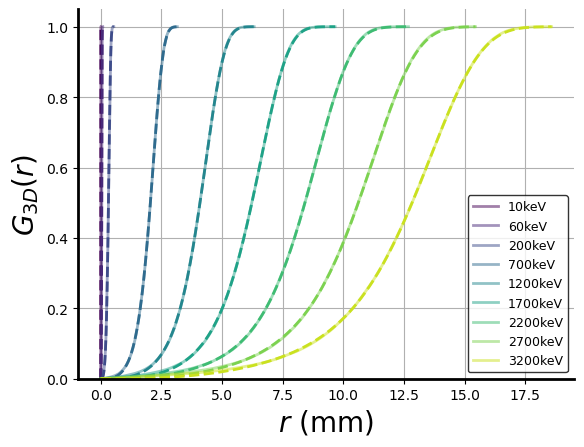

In [51]:
params = np.zeros((len(data), 5))
colors = dict()
for i, E in enumerate(data.keys()):
    colors[E] = plt.cm.viridis(i / len(data))

def fit_func(x, a1, n1, a2, n2):
    return 1 - np.exp(-((a1*x)**n1 + (a2*x)**n2))

for nit, (Es, PRs) in enumerate(data.items()):
    sorted_PRs = np.sort(PRs).astype(float)
    E = int(Es.split("keV")[0])
    G3D = np.arange(1, len(sorted_PRs) + 1) / len(sorted_PRs)

    popt, _ = curve_fit(
        fit_func,
        sorted_PRs,
        G3D,
        p0=[1, 1.5, 1, 2.5],
        maxfev=10000,
        bounds=(
            [0, 1, 0, 1],      # lower bounds for a1, n1, a2, n2, a3, n3
            [np.inf, 10, np.inf, 10]  # upper bounds for a1, n1, a2, n2, a3, n3
        )
    )
    (a1, n1), (a2, n2) = sorted([[popt[i], popt[i+1]] for i in range(0, len(popt), 2)], key=lambda x: x[1])
    params[nit, :] = E, a1, n1, a2, n2
    print(f"Fit parameters for {E} keV: a1={a1:.2e}, n1={n1:.2f}, a2={a2:.2e}, n2={n2:.2f}")
    if nit % 10 == 0:
        plt.plot(sorted_PRs, G3D, '-', label=f"{E}keV", lw=2, alpha=0.5, color=colors[Es])
        plt.plot(sorted_PRs, fit_func(sorted_PRs, *popt), '--', lw=2, color=colors[Es])
plt.xlabel(r"$r$ (mm)")
plt.ylabel(r"$G_{3D}(r)$")
# plt.xscale('log')
plt.legend()
from analysis import aesthetic_plot
aesthetic_plot()
params[:,1::2] = 1/params[:,1::2]  # lambda = 1/a

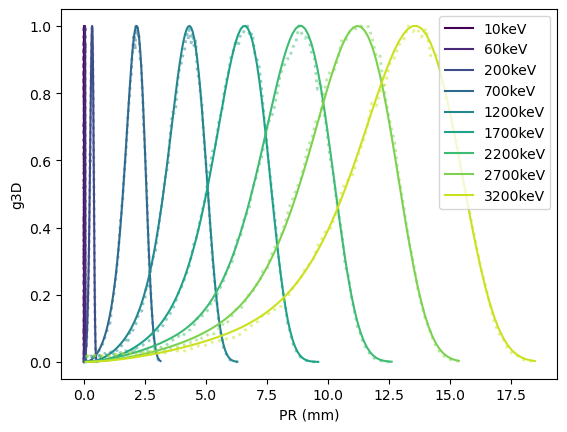

In [52]:
def g3D_func(x, l1, n1, l2, n2):
    term = (x/l1)**n1 + (x/l2)**n2
    dterm = n1/l1 * (x/l1)**(n1 - 1) + n2/l2 * (x/l2)**(n2 - 1)
    return np.exp(-term) * dterm

for nit, (E, PRs) in enumerate(data.items()):
    if nit%10 != 0: continue
    hist, bin_edges = np.histogram(PRs, bins=100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist /= np.max(hist)  # Normalize the histogram
    plt.plot(bin_centers, hist, ':', lw=2, alpha=0.5, color=colors[E])

    l1, n1, l2, n2 = params[nit, 1:]
    # Compute the theoretical g3D distribution
    g3D_theoretical = g3D_func(bin_centers, l1, n1, l2, n2)
    g3D_theoretical /= np.max(g3D_theoretical)  # Normalize the theoretical distribution
    plt.plot(bin_centers, g3D_theoretical, '-', label=f"{E}keV", lw=1.5, color=colors[E])
    
    # LAMBDA = np.mean(PRs) / (np.std(PRs)/(2*np.sqrt(2*np.log(2))))  # FWHM
    # print(f"Mean PR for {E} keV: {np.mean(PRs):.2e} mm, Lambda: {LAMBDA:.2e}")
    # # Compute Poisson distribution using mean_PR as lambda
    # k = np.arange(1, len(bin_centers) + 1)
    # poisson = (LAMBDA ** k) * np.exp(-LAMBDA) / factorial(k)
    # poisson /= np.max(poisson)  # Normalize
    
    # # Plot the Poisson fit as a dashed line
    # plt.plot(bin_centers, poisson, '-', label=f"{E}keV Poisson Fit", lw=1.5)   
    # break
    
plt.xlabel("PR (mm)")
plt.ylabel("g3D")
# plt.xscale('log')
plt.legend()

Fit for a1: A = 8.73e-04, B = 1.10e+00
Fit for a2: A = 3.51e-05, B = 1.77e+00
Fit for n1: A = 9.89e-01, B = 1.92e-01, C = 1.00e+00
Fit for n2: A = 8.34e-01, B = 6.23e+00, C = 1.00e+00


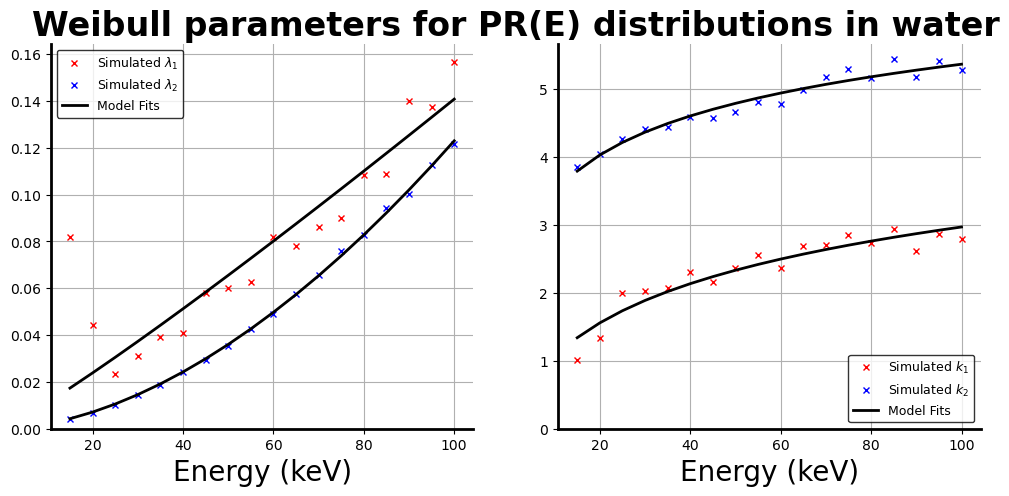

In [ ]:
pp = params[0:, ...]

# Define the fitting functions
def lambda_func(x, A, B):
    return A * x**B #A*(np.sqrt(x**2 + B**2) - B)

def n_func1(x, A, B):
    return A * np.log(1 + B*x)

def n_func2(x, A, B, C):
    return A * np.log(1 + B*x) #- C*x  # A * np.log(1 + B*x) - C*x

plt.figure(figsize=(12, 5))
plt.title("Weibull parameters for PR(E) distributions in water", fontsize=24, fontweight='bold')
plt.gca().set_axis_off()
# Fit and plot parameter "a" with an exponential function
plt.subplot(1, 2, 1)
plt.plot(pp[:, 0], pp[:, 1], 'x', markersize=5, color="red", label=r"Simulated $\lambda_1$")
plt.plot(pp[:, 0], pp[:, 3], 'x', markersize=5, color="blue", label=r"Simulated $\lambda_2$")

popt_l1, _ = curve_fit(lambda_func, pp[:, 0], pp[:, 1], p0=[1, 0.001])
plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l1), 'k-', lw=5, zorder=10)  # label=r"Model Fit: $\lambda_1$"
print("Fit for a1: A = %.2e, B = %.2e" % (popt_l1[0], popt_l1[1]))

popt_l2, _ = curve_fit(lambda_func, pp[:, 0], pp[:, 3], p0=[1, 0.001])
plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l2), 'k-', label=r"Model Fits", lw=5, zorder=10)
print("Fit for a2: A = %.2e, B = %.2e" % (popt_l2[0], popt_l2[1]))

plt.xlabel("Energy (keV)")
# plt.ylabel(r"$\lambda$", rotation=0)
# plt.xscale('log')
plt.legend()
ax, leg = aesthetic_plot()
ax.set_ylim(-0., None)

# Fit and plot parameter "n" with a logarithmic function
plt.subplot(1, 2, 2)
plt.plot(pp[:, 0], pp[:, 2], 'x', markersize=5, color="red", label=r"Simulated $k_1$")
plt.plot(pp[:, 0], pp[:, 4], 'x', markersize=5, color="blue", label=r"Simulated $k_2$")

popt_n1, _ = curve_fit(n_func2, pp[:, 0], pp[:, 2], p0=(1, 1, 1))
plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n1), 'k-', lw=5, zorder=10)
print("Fit for n1: A = %.2e, B = %.2e, C = %.2e" % (popt_n1[0], popt_n1[1], popt_n1[2]))

popt_n2, _ = curve_fit(n_func2, pp[:, 0], pp[:, 4], p0=(1, 1, 1))
plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n2), 'k-', lw=5, zorder=10, label="Model Fits")
print("Fit for n2: A = %.2e, B = %.2e, C = %.2e" % (popt_n2[0], popt_n2[1], popt_n2[2]))

plt.xlabel("Energy (keV)")
# plt.ylabel(r"$k$", rotation=0)
plt.title
# plt.yscale('log')
plt.legend()
ax, leg = aesthetic_plot()
# ax.set_ylim(3.5, None)

R2 for C11: -138.357
MAPE for C11: 121564.3 %
Mean simulated PR for C11: 0.78 mm
Mean generated PR for C11: 3.71 mm (378.1%)
----------------------
R2 for N13: -14.463
MAPE for N13: 41733.2 %
Mean simulated PR for N13: 1.11 mm
Mean generated PR for N13: 4.11 mm (268.2%)
----------------------
R2 for O15: nan
MAPE for O15: nan %


IndexError: index -1 is out of bounds for axis 0 with size 0

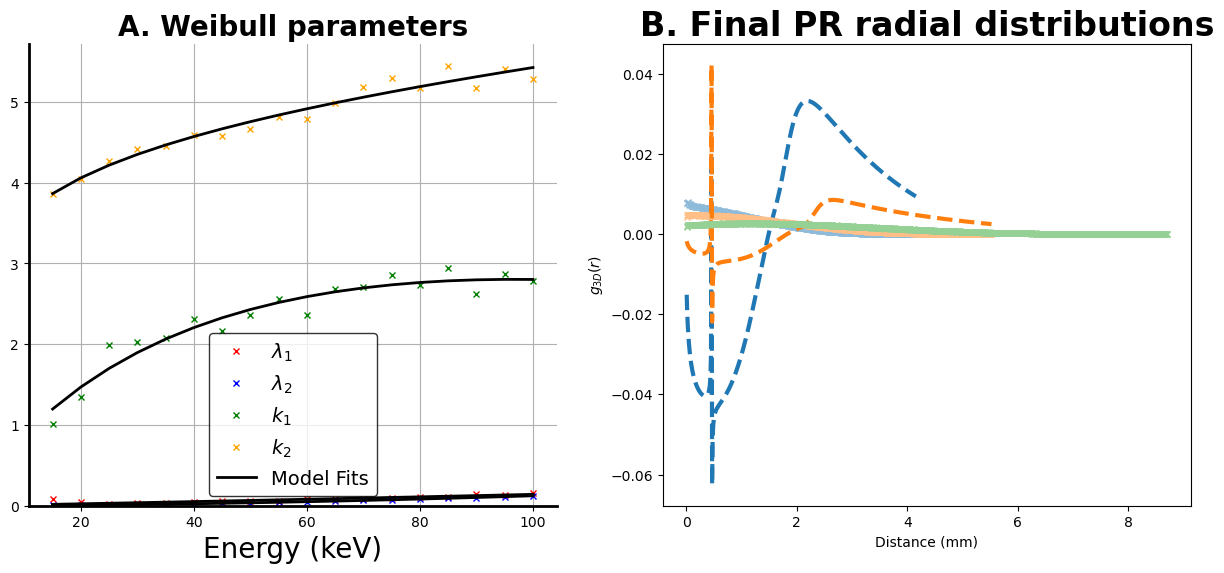

In [33]:
from matplotlib.lines import Line2D

##############################################################################################################################
plt.figure(figsize=(15, 6))
# plt.subplot(1, 3, (1, 2))
plt.subplot(1, 2, 1)
plt.title("A. Weibull parameters", fontsize=24, fontweight='bold', loc='center')
# plt.gca().set_axis_off()
plt.plot(pp[:, 0], pp[:, 1], 'x', markersize=5, color="red", label=r"$\lambda_1$")
plt.plot(pp[:, 0], pp[:, 3], 'x', markersize=5, color="blue", label=r"$\lambda_2$")
plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l1), 'k-', lw=5, zorder=10)  # label=r"Model Fit: $\lambda_1$"
plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l2), 'k-', lw=5, zorder=10)
plt.plot(pp[:, 0], pp[:, 2], 'x', markersize=5, color="green", label=r"$k_1$")
plt.plot(pp[:, 0], pp[:, 4], 'x', markersize=5, color="orange", label=r"$k_2$")
plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n1), 'k-', lw=5, zorder=10)
plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n2), 'k-', lw=5, zorder=10, label="Model Fits")

plt.xlabel("Energy (keV)")
plt.legend()
# plt.yscale('log')
ax, leg = aesthetic_plot(legend_size=14)
##############################################################################################################################

material = "Water"
code, coden = "PenEasy2024", "PenEasy 2024"
isotopes = ["C11", "N13", "O15", "F18", "Cu64", "Ga68", "Rb82", "I124"]
colors = dict()
color_list = plt.cm.tab10.colors

def brighten(color, factor=0.5):
    # Increase brightness by mixing with white
    return tuple(min(1, comp + factor * (1 - comp)) for comp in color)

colors = dict()
for i, iso in enumerate(isotopes):
    dark = color_list[i % len(color_list)]
    light = brighten(dark, factor=0.5)
    colors[iso] = {"dark": dark, "light": light}

# plt.figure(figsize=(7, 6))
plt.subplot(1, 2, 2)
mg3D = dict().fromkeys(isotopes, None)
for isotope in isotopes:
    input_file = f"RESULTS/SPC/{material}/{code}_xyz/{isotope}.dat" # in cm

    bs = 1e-3
    rr, G3D = fitPRd.load_nonhisto_G3D(input_file) 
    rp, g3D = fitPRd.load_nonhisto_g3D(input_file, tol=bs)

    # plt.subplot(1, 2, 2)
    plt.title(f"B. Final PR radial distributions", fontsize=24, fontweight='bold')
    plt.xlabel(r"Distance (mm)")
    plt.ylabel(r"$g_{3D}(r)$")
    plt.plot(rp*10, g3D/g3D.sum(), 'x', markersize=5, color=colors[isotope]["light"], lw=3)

    def P(r, E):
        l1 = lambda_func(E, *popt_l1)
        l2 = lambda_func(E, *popt_l2)
        n1 = n_func2(E, *popt_n1)
        n2 = n_func1(E, *popt_n2)

        # Weibull distribution
        term = (r/l1)**n1 + (r/l2)**n2
        dterm = n1/l1 * (r/l1)**(n1 - 1) + n2/l2 * (r/l2)**(n2 - 1)
        P = np.exp(-term) * dterm  # P(r|E)
        return P

    if isotope in betaplus.SB:
        Z, A = betaplus.SB[isotope]['Z'], betaplus.SB[isotope]['A']
        branches = betaplus.SB[isotope]['branches']  
    elif isotope in betaplus.MB:
        Z, A = betaplus.MB[isotope]['Z'], betaplus.MB[isotope]['A']
        branches = betaplus.MB[isotope]['branches']


    gg3D = np.zeros((len(branches), len(rp)))
    for nb, (nat, Emax, Emean, w) in enumerate(branches):
        E, N, N0 = betaplus.beta_spectrum(Emax, Z, A, nat)

        mask = E > 3    # keV
        E = E[mask]
        N = N[mask]
        # Extend E and N from Emax to 2*Emax
        E_ext = np.linspace(E[-1], 3 * Emax, num=1000, endpoint=True)[1:]
        N_ext = np.zeros_like(E_ext)
        E = np.concatenate((E, E_ext))
        N = np.concatenate((N, N_ext))

        # Pre-compute l and k values for all energies
        l1_values = lambda_func(E, *popt_l1)
        l2_values = lambda_func(E, *popt_l2)
        n1_values = n_func2(E, *popt_n1)
        n2_values = n_func2(E, *popt_n2)
        dE = np.gradient(E)

        # For each distance
        # plt.subplot(1, 2, 1)
        for i, r in enumerate(rp*10):
            if r < 1e-4: continue
            # Calculate P(r|E) for all energies at once
            term = (r/l1_values)**n1_values + (r/l2_values)**n2_values
            dterm = n1_values/l1_values * (r/l1_values)**(n1_values - 1) + n2_values/l2_values * (r/l2_values)**(n2_values - 1)
            P = np.exp(-term) * dterm 
            P /= np.sum(P)  # Normalize 
            PN = P * N
            # if i % 50 == 0: 
            #     plt.plot(E, PN/PN.sum(), '-', lw=3, label=f"r={r:.2f} mm")
            # Weight by N and sum
            gg3D[nb, i] = np.sum(PN * dE)

        # plt.xlim(0, Emax)
        # plt.title(r"$\mathbf{g_{3D}(E|r)}$" + f" for {isotope}", fontsize=24, fontweight='bold')
        # plt.yscale('log')
        # plt.xlabel("Energy (keV)")
        # plt.ylabel(r"$P(r|E) \cdot N(E)$")
        # plt.ylim(1e-5, 1)
        # ax, leg = aesthetic_plot()


        gg3D[nb,:] *= w / np.sum(gg3D[nb,:])  # Normalize the theoretical distribution

    gg3D = np.sum(gg3D, axis=0)  # Sum over branches
    gg3D /= np.sum(gg3D)  # Normalize the theoretical distribution
    mg3D[isotope] = np.array([rp*10, gg3D])
    # plt.subplot(1, 2, 2)
    plt.plot(rp*10, gg3D, '--', color=colors[isotope]["dark"], alpha=1, lw=3, zorder=2)
    ng3D = g3D/g3D.sum()
    mape = np.sum(np.abs(gg3D - ng3D) / ng3D) / len(ng3D) * 100
    r2 = 1 - np.sum((gg3D - ng3D)**2) / np.sum((ng3D - np.mean(ng3D))**2)
    print(f"R2 for {isotope}: {r2:.3f}")
    print(f"MAPE for {isotope}: {mape:.1f} %")
    sim_G3D = np.cumsum(ng3D)
    theo_G3D = np.cumsum(gg3D)
    sim_rmean  = rp[sim_G3D  <=0.5][-1]*10
    theo_rmean = rp[theo_G3D <=0.5][-1]*10
    print(f"Mean simulated PR for {isotope}: {sim_rmean:.2f} mm")
    print(f"Mean generated PR for {isotope}: {theo_rmean:.2f} mm ({(theo_rmean-sim_rmean)/sim_rmean*100:.1f}%)")

    print("----------------------")
    # plt.yscale('log')
plt.yscale('log')
# plt.xscale('log')
plt.ylim(1e-5, None)
ax, leg = aesthetic_plot(linewidth=3)
handles = [Line2D([], [], color=colors[iso]["dark"], lw=3, linestyle='-') for iso in isotopes]
isop = [f"{iso_in_plots(iso)}" for iso in isotopes]
leg = plt.legend(handles, isop, prop={'size': 14})
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1)



Isotope: F18


100%|██████████| 68921/68921 [01:43<00:00, 665.27it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.06
		Maximum abs deviation: 9.27%
		R2: -inf
		Mean blur radius (VG): 1.10 mm
		Mean blur radius (sim): 0.94 mm
		FWHM (sim): 0.65 mm
		FWHM (VG): 0.71 mm (9.3%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.02
		Maximum abs deviation: 3.65%
		R2: -inf
		Mean blur radius (VG): 1.37 mm
		Mean blur radius (sim): 1.33 mm
		FWHM (sim): 0.87 mm
		FWHM (VG): 0.92 mm (5.6%)
Isotope: Ga68


100%|██████████| 68921/68921 [02:04<00:00, 552.55it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.02
		Maximum abs deviation: 14.54%
		R2: 0.70
		Mean blur radius (VG): 5.66 mm
		Mean blur radius (sim): 5.13 mm
		FWHM (sim): 1.78 mm
		FWHM (VG): 2.21 mm (24.2%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 10.74%
		R2: 0.62
		Mean blur radius (VG): 5.70 mm
		Mean blur radius (sim): 5.31 mm
		FWHM (sim): 2.02 mm
		FWHM (VG): 2.43 mm (20.4%)
Isotope: Rb82


100%|██████████| 68921/68921 [02:33<00:00, 448.59it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 13.42%
		R2: 0.66
		Mean blur radius (VG): 10.82 mm
		Mean blur radius (sim): 10.08 mm
		FWHM (sim): 3.73 mm
		FWHM (VG): 4.67 mm (25.2%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 11.05%
		R2: 0.70
		Mean blur radius (VG): 10.84 mm
		Mean blur radius (sim): 10.26 mm
		FWHM (sim): 4.02 mm
		FWHM (VG): 4.87 mm (21.1%)


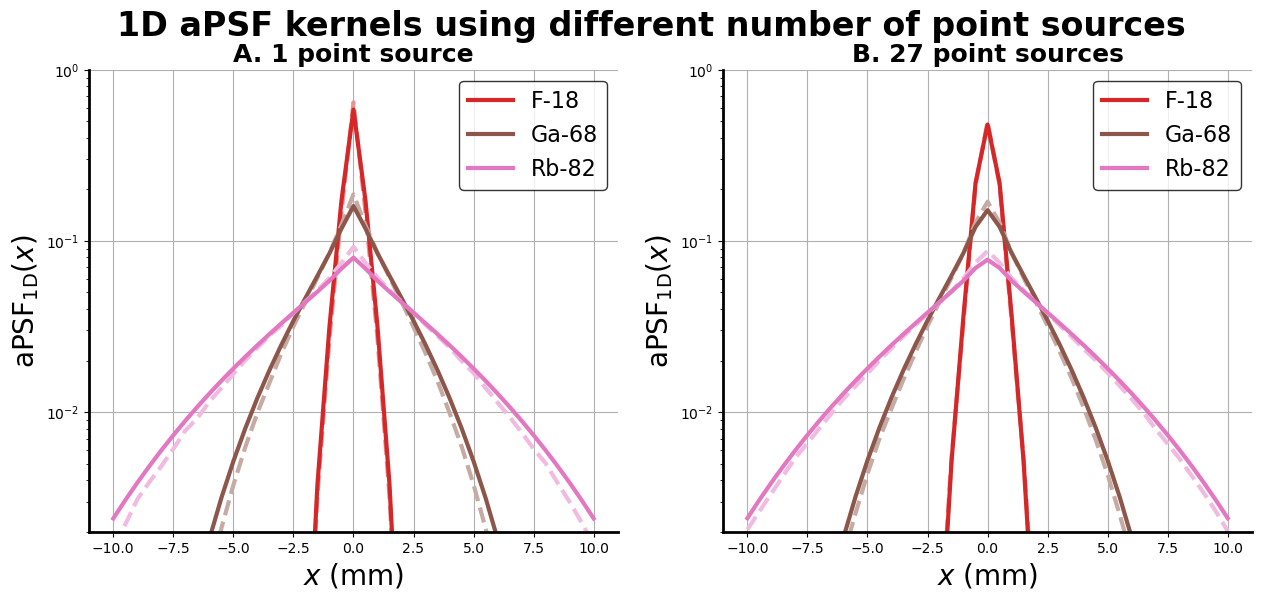

In [32]:
from kernel import VG
from analysis import PRAnalysis

def get_g3D_func(isotope):
    rp, g3D = mg3D[isotope]
    func = lambda r: np.interp(r, rp, g3D)
    return func

def fwhm(x, y):
    half_max = y.max() / 2
    peak_idx = np.argmax(y)

    # find left crossing
    iL = np.where(y[:peak_idx] < half_max)[0][-1]
    iLp = iL + 1
    xL = x[iL] + (half_max - y[iL]) * (x[iLp] - x[iL]) / (y[iLp] - y[iL])

    # find right crossing
    iR = peak_idx + np.where(y[peak_idx:] < half_max)[0][0]
    iRp = iR - 1
    xR = x[iRp] + (half_max - y[iRp]) * (x[iR] - x[iRp]) / (y[iR] - y[iRp])

    fwhm = xR - xL
    return fwhm

code = "PenEasy2024"
material = "Water"
kernel_size = [41]*3
kernel_step = [50e-2/10]*3 # voxel size in cm

nx, ny, nz = kernel_size
cx, cy, cz = (nx-1)/2, (ny-1)/2, (nz-1)/2
x = np.arange(nx)[:,None,None]
y = np.arange(ny)[None,:,None]
z = np.arange(nz)[None,None,:]
D = np.sqrt((x-cx)**2 + (y-cy)**2 + (z-cz)**2)

isotopes = ["F18", "Ga68", "Rb82"]

fig = plt.figure(figsize=(15, 6))
fig.suptitle(f"1D aPSF kernels using different number of point sources", fontsize=24, fontweight='bold')
plt.gca().set_axis_off()
for iso in isotopes:
    input_file_S1 = f"RESULTS/SPC/{material}/{code}_xyz/{iso}.dat" # in cm
    simul_data_S1 = PRAnalysis(f"{iso} S1", input_file_S1, SIZE=kernel_size, STEP=kernel_step) 
    xdata = simul_data_S1.xp*10
    real_aPSFx_S1 = simul_data_S1.aPSFx
    aPSF_kernel_sim_S1 = simul_data_S1.img / simul_data_S1.img.sum()

    input_file_S3 = f"RESULTS/kernel/{material}/{code}_xyz/simulated_{iso}_S3.dat" # in cm
    simul_data_S3 = PRAnalysis(f"{iso} S3", input_file_S3, SIZE=kernel_size, STEP=kernel_step) 
    xdata = simul_data_S3.xp*10
    real_aPSFx_S3 = simul_data_S3.aPSFx
    aPSF_kernel_sim_S3 = simul_data_S3.img / simul_data_S3.img.sum()

    print(f"Isotope: {iso}")
    # print(f"\tMaximum kernel PR in x-axis: {simul_data.Xmax*10:.2f} mm")
    # print(f"\tMaximum simulated PR: {simul_data.rmax*10:.2f} mm")
    # print(f"\t90% yield simulated PR: {simul_data.interpol_G3D(0.9)*10:.2f} mm")
    # print(f"\t99% yield simulated PR: {simul_data.interpol_G3D(0.99)*10:.2f} mm")
    # print(f"\tVoxel step size: {kernel_step[0]*10:.2f} mm")

    # Get modeled aPSF3D
    g3D = get_g3D_func(iso)
    aPSF3D_tmp = lambda _r: g3D(_r)/_r**2
    rmin = 1e-8
    aPSF3D = lambda _r: aPSF3D_tmp(np.where(_r < rmin, rmin, _r))
    aPSF_kernel_VG_S1 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=1, disable_tqdm=False)
    aPSF_kernel_VG_S3 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=3, disable_tqdm=False)

    kernel_aPSFx_S1 = np.sum(aPSF_kernel_VG_S1, axis=(1, 2))
    kernel_aPSFx_S1 /= kernel_aPSFx_S1.sum()
    kernel_aPSFx_S3 = np.sum(aPSF_kernel_VG_S3, axis=(1, 2))
    kernel_aPSFx_S3 /= kernel_aPSFx_S3.sum()
    real_aPSFx_S1 /= real_aPSFx_S1.sum()
    real_aPSFx_S3 /= real_aPSFx_S3.sum()
    XX_S1 = simul_data_S1.aPSFx_range*10
    XX_S3 = simul_data_S3.aPSFx_range*10

    rmask = 0.99
    for S, XX, simul_data, kernel_aPSFx, real_aPSFx, aPSF_kernel_VG, aPSF_kernel_sim in zip([1, 3], 
                                                                                            [XX_S1, XX_S3], 
                                                                                            [simul_data_S1, simul_data_S3], 
                                                                                            [kernel_aPSFx_S1, kernel_aPSFx_S3], 
                                                                                            [real_aPSFx_S1, real_aPSFx_S3],
                                                                                            [aPSF_kernel_VG_S1, aPSF_kernel_VG_S3],
                                                                                            [aPSF_kernel_sim_S1, aPSF_kernel_sim_S3]):
        mask = abs(XX) <= simul_data.interpol_G3D(rmask)
        res = kernel_aPSFx - real_aPSFx
        print(f"\tS{S} kernel from x=0 to |x|=r_{rmask*100}%:")

        rmse = np.sqrt(np.sum(res[mask]**2) / len(res[mask]))
        print(f"\t\tRMSE: {rmse:.2f}")

        deviation = np.abs(res[mask] / real_aPSFx[mask]) * 100
        print(f"\t\tMaximum abs deviation: {deviation.max():.2f}%")

        r2 = 1.0 - np.sum(res[mask]**2) / np.sum((real_aPSFx[mask]-np.mean(real_aPSFx[mask]))**2)
        print(f"\t\tR2: {r2:.2f}")

        mean_blur_radius_VG = np.sum(aPSF_kernel_VG * D) / np.sum(aPSF_kernel_VG)
        mean_blur_radius_sim = np.sum(aPSF_kernel_sim * D) / np.sum(aPSF_kernel_sim)
        print(f"\t\tMean blur radius (VG): {mean_blur_radius_VG:.2f} mm")
        print(f"\t\tMean blur radius (sim): {mean_blur_radius_sim:.2f} mm")

        nkernel_aPSFx = kernel_aPSFx / np.max(kernel_aPSFx)
        nreal_aPSFx = real_aPSFx / np.max(real_aPSFx)
        FWHM_VG = fwhm(XX, nkernel_aPSFx)
        FWHM_sim = fwhm(XX, nreal_aPSFx)
        print(f"\t\tFWHM (sim): {FWHM_sim:.2f} mm")
        print(f"\t\tFWHM (VG): {FWHM_VG:.2f} mm ({(FWHM_VG-FWHM_sim)/FWHM_sim*100:.1f}%)")


    # plt.plot(simul_data.aPSFx_range[mask]*10, deviation, label=f"{iso_in_plots(iso)}")
    plt.subplot(121)
    real_aPSFx_S1 /= real_aPSFx_S1.sum()
    kernel_aPSFx_S1 /= kernel_aPSFx_S1.sum()
    plt.plot(XX_S1, real_aPSFx_S1, '--', markersize=10, color=colors[iso]["light"])
    plt.plot(XX_S1, kernel_aPSFx_S1, '-', color=colors[iso]["dark"])
    plt.subplot(122)
    real_aPSFx_S3 /= real_aPSFx_S3.sum()
    kernel_aPSFx_S3 /= kernel_aPSFx_S3.sum()
    plt.plot(XX_S3, real_aPSFx_S3, '--', markersize=10, color=colors[iso]["light"])
    plt.plot(XX_S3, kernel_aPSFx_S3, '-', color=colors[iso]["dark"])

fig_id = ["A", "B"]
for i, S in enumerate([1, 3]):
    plt.subplot(1,2,1+i)
    plt.xlabel(r"$x$ (mm)")
    plt.ylabel(r"$\mathrm{aPSF}_\mathrm{1D}(x)$")
    for iso in isotopes:
        plt.plot([], [] , '-', label=iso_in_plots(iso), color=colors[iso]["dark"])
    # plt.plot([], [] , '-', label="Simulated", color='black')
    # plt.plot([], [] , ':', label="Generated", color='black')
    plt.legend(ncols=2)
    plt.yscale('log')
    plt.ylim(2e-3, 1)
    ax, leg = aesthetic_plot(legend_size=16, linewidth=3)
    ax.set_title(f"{fig_id[i]}. {S**3} point source{'s' if S>1 else ''}", fontsize=18, fontweight='bold')

plt.show()
# plt.subplot(122)
# iso = "Rb82"
# g3D = get_g3D_func(iso)
# aPSF3D_tmp = lambda _r: g3D(_r)/_r**2
# rmin = 1e-8
# aPSF3D = lambda _r: aPSF3D_tmp(np.where(_r < rmin, rmin, _r))

# input_file = f"RESULTS/kernel/{material}/{code}_xyz/simulated_{iso}_S3.dat" # in cm
# simul_data = PRAnalysis(f"{iso} kernel", input_file, SIZE=kernel_size, STEP=kernel_step) 
# aPSF_kernel_sim_S3 = simul_data.img / simul_data.img.sum()

# # aPSF_kernel_VG_S3 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=5, disable_tqdm=False)
# dev = np.abs(aPSF_kernel_VG_S3 - aPSF_kernel_sim_S3)#*1e3 / (aPSF_kernel_sim_S3*1e3) * 100
# # mask = (aPSF_kernel_sim_S3 < 1e-4)
# # dev[mask] = 0
# maxdev = np.max(dev)
# mindev = np.min(dev)
# dev_flat = dev.flatten()
# unique_devs = np.unique(dev_flat)
# if unique_devs.size > 1:
#     second_min = unique_devs[1]
# else:
#     second_min = unique_devs[0]
# print(f"Second minimum deviation: {second_min:.2f}%, {second_min:.2e}")
# print(f"Maximum deviation: {maxdev:.2f}%, {maxdev:.2e}")
# print(f"Minimum deviation: {mindev:.2f}%, {mindev:.2e}")

# from matplotlib import ticker

# midz = dev.shape[2] // 2
# ñ = midz
# DEV = np.sum(dev[...,midz-ñ:midz+ñ+1], axis=2)
# minDEV = np.min(DEV)
# maxDEV = np.max(DEV)

# print(f"Maximum deviation: {maxDEV:.2f}%, {maxDEV:.2e}")
# print(f"Minimum deviation: {minDEV:.2f}%, {minDEV:.2e}")

# # Define white at 0% deviation
# from matplotlib.colors import TwoSlopeNorm
# # norm = TwoSlopeNorm(vmin=minDEV, vcenter=0.0, vmax=maxDEV)

# # plt.imshow(np.abs(DEV), cmap='binary', interpolation=None)
# # plt.imshow(aPSF_kernel_VG_S3[:,:,midz], cmap='binary', interpolation=None)
# plt.xlabel(r"$x$ (voxel)", fontsize=20)
# plt.ylabel(r"$y$ (voxel)", fontsize=20)
# cbar = plt.colorbar(shrink=0.8)
# # cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%'))
# cbar.ax.yaxis.set_offset_position('left')
# cbar.formatter.set_powerlimits((0, 0))
# cbar.formatter.set_useMathText(True)
# plt.title(f"B. Differences of our method\nagainst the MC simulation", fontsize=18, fontweight='bold')
# plt.show()